In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

✅ All libraries loaded successfully!
NumPy: 2.0.2
Pandas: 2.2.2


(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Missing values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who           

/tmp/ipykernel_701/3078284250.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_701/3078284250.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

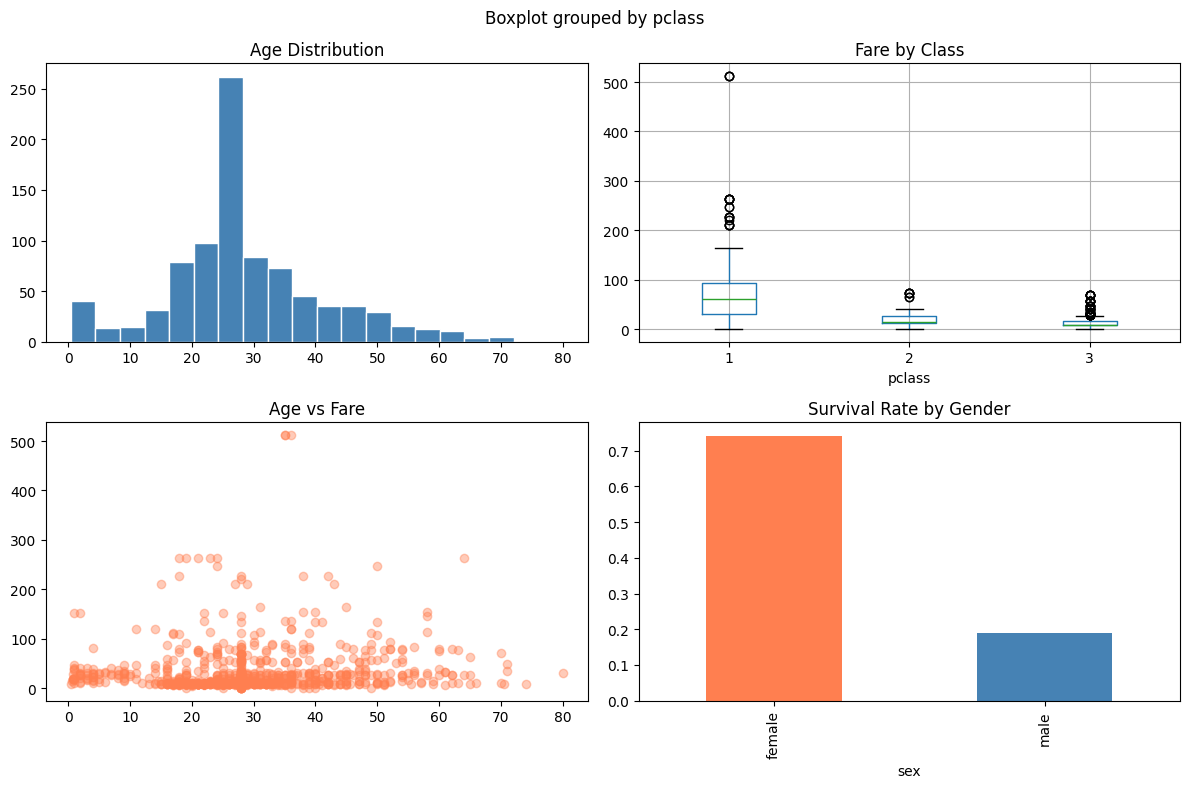

✅ Plots saved!

📊 Linear Regression Results:
   MAE : 25.45
   RMSE: 39.05


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = sns.load_dataset('titanic')
print(df.shape)
print(df.head())

# Beginner Task 2: Basic cleaning
print("\n--- Missing values ---")
print(df.isnull().sum())

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop(columns=['deck'], inplace=True)
print("\n✅ Cleaning done. Missing values left:", df.isnull().sum().sum())

# Beginner Task 3: 4 plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Titanic EDA', fontsize=14)

# Histogram
axes[0,0].hist(df['age'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')

# Boxplot
df.boxplot(column='fare', by='pclass', ax=axes[0,1])
axes[0,1].set_title('Fare by Class')

# Scatter
axes[1,0].scatter(df['age'], df['fare'], alpha=0.4, color='coral')
axes[1,0].set_title('Age vs Fare')

# Bar
survived = df.groupby('sex')['survived'].mean()
survived.plot(kind='bar', ax=axes[1,1], color=['coral','steelblue'])
axes[1,1].set_title('Survival Rate by Gender')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plots saved!")

# Beginner Task 4: Linear regression (age predicting fare)
from sklearn.model_selection import train_test_split

clean = df[['age','fare']].dropna()
X = clean[['age']]
y = clean['fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"\n📊 Linear Regression Results:")
print(f"   MAE : {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")